# Real case: Mannsworth - Tomo2D 

This notebook implements the Tomography-like approach on data from [Barone et al. (2021)](https://doi.org/10.1007/s10712-021-09631-x)

In [1]:
from pyswapp import *

/home/alberto/anaconda3/envs/pyswapp/lib/python3.9/site-packages/obspy/core/util/base.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# directories
prj_dir = '../../data/real_data' # project directory
path2raw = os.path.join(prj_dir,'raw') # path to raw data
path2geom = f'{prj_dir}/Geometry_mannsworth.csv' # path to the geometry file

In [3]:
# processing and plotting settings
settings = create_settings(fmin=5, fmax=30,                  # frequency range
                         vmin=10, vmax=500, velstep=1)     # testing phase velocity range and step

In [4]:
swam = Tomo2DManager(f'{prj_dir}/proc/tomo2D',             # project directory path
                   path2raw=path2raw,                       # optional, copy & per default rename data from path (outside project directory)
                   path2geom=path2geom,                     # optional, copy geom from path (outside project directory)
                   settings=settings,                       # optional, define settings for visualisations and processing
                   rename = False,                          # optional, rename copied raw data to preferred filename format (Shotfile_<index>), default value is False!
                   overwrite = False,                       # optional, overwrite database .db file if it already exists --> create new project data base
                   )

Loading project:
Reading seismic shot files ..... 10.33 s
Read 82 files and applied geometry and settings.
Active procset label: tomo2D

Existing procsets: raw proc1 tomo2D
Loading amplitude data from "tomo2D" ..... 0.25 s



In [5]:
# set a new procset label
procset = 'tomo2D'
swam.set_procset_label(procset)

Active procset label: tomo2D


In [6]:
# Retrieve subsets from data corresponding to forward and reverse shots
swam.prepare_streams(min_offset=5, #max_offset=1e6,
                     min_rec =12, #max_rec=None
                    )

Trimming data based on offset (SIN,REP) = (43, 2) ..... 9.67 s


### A. Pick interactively the FK filter

In [7]:
# Isolate the fundamental mode in FK domain
swam.gui_interact('filter','FK')

Loading the GUI ..... 2.32 s
Applying FK filter to (SIN,REP,WID) = (1, 1, 0) and writing to database..... 0.08 s
Applying FK filter to (SIN,REP,WID) = (1, 2, 0) and writing to database..... 0.08 s
Applying FK filter to (SIN,REP,WID) = (2, 1, 0) and writing to database..... 0.08 s
Applying FK filter to (SIN,REP,WID) = (2, 2, 0) and writing to database..... 0.07 s
Applying FK filter to (SIN,REP,WID) = (3, 1, 0) and writing to database..... 0.07 s
Applying FK filter to (SIN,REP,WID) = (3, 2, 0) and writing to database..... 0.08 s
Applying FK filter to (SIN,REP,WID) = (4, 1, 0) and writing to database..... 0.08 s
Applying FK filter to (SIN,REP,WID) = (4, 2, 0) and writing to database..... 0.07 s
Applying FK filter to (SIN,REP,WID) = (5, 1, 0) and writing to database..... 0.09 s
Applying FK filter to (SIN,REP,WID) = (5, 2, 0) and writing to database..... 0.08 s
Applying FK filter to (SIN,REP,WID) = (6, 1, 0) and writing to database..... 0.07 s
Applying FK filter to (SIN,REP,WID) = (6, 2, 0)

In [8]:
# save picked filter from database to disk for whole procset
swam.save_filter(fname = f'{prj_dir}/proc/FKfilter.txt', ftype='FK')

### B. Apply an existing FK filter

In [7]:
# Filter in FK based on a file containing the filter (points along line to mute data abov or below)
path2fk = f'{prj_dir}/proc/FKfilter.txt' # path to the geometry file

swam.import_filter(fname = path2fk)
swam.apply_filter(ftype = 'FK')

Applying FK filter to (SIN,REP) = (43, 2) ..... 76.61 s


## Phase diff and run tomo

In [8]:
# compute phase differences
swam.compute_phasediff()

Calculating phase differences for (SIN,REP) = (43,2) ..... 6.15 s
Calculating mean and std of phase differences for (SIN) = (43) ..... 2.01 s


In [9]:
# offset in meters
min_offset = 10 
max_offset = 12
err_r = 2/100
lam = 20

typ = 'tomo2D'

# Run the tomo2D
swam.run(lam = lam, min_offset = min_offset, max_offset = max_offset, rel_err = err_r)
#swam.run(min_offset = min_offset, max_offset = max_offset, rel_err = err_r, opt_lam=True)

Running tomographic-like approach
  5.00 Hz | Cost = 1.517
  5.50 Hz | Cost = 1.137
  6.00 Hz | Cost = 1.586
  6.50 Hz | Cost = 0.953
  7.00 Hz | Cost = 1.065
  7.50 Hz | Cost = 0.901
  8.00 Hz | Cost = 0.832
  8.50 Hz | Cost = 0.823
  9.00 Hz | Cost = 0.819
  9.50 Hz | Cost = 0.723
 10.00 Hz | Cost = 0.766
 10.50 Hz | Cost = 0.817
 11.00 Hz | Cost = 0.602
 11.50 Hz | Cost = 0.677
 12.00 Hz | Cost = 0.773
 12.50 Hz | Cost = 0.856
 13.00 Hz | Cost = 1.033
 13.50 Hz | Cost = 1.024
 14.00 Hz | Cost = 0.871
 14.50 Hz | Cost = 0.822
 15.00 Hz | Cost = 0.885
 15.50 Hz | Cost = 1.046
 16.00 Hz | Cost = 1.154
 16.50 Hz | Cost = 1.021
 17.00 Hz | Cost = 1.081
 17.50 Hz | Cost = 1.375
 18.00 Hz | Cost = 3.241
 18.50 Hz | Cost = 1.782
 19.00 Hz | Cost = 1.081
 19.50 Hz | Cost = 1.162
 20.00 Hz | Cost = 2.098
 20.50 Hz | Cost = 1.533
 21.00 Hz | Cost = 1.747
 21.50 Hz | Cost = 1.660
 22.00 Hz | Cost = 1.398
 22.50 Hz | Cost = 2.765
 23.00 Hz | Cost = 1.369
 23.50 Hz | Cost = 1.615
 24.00 Hz | Cost

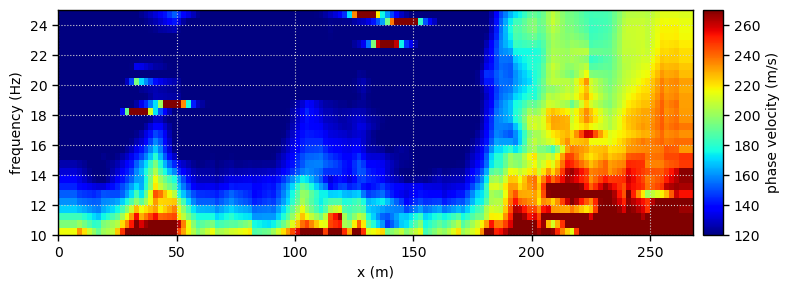

In [10]:
# plot pseudosection
c_map = 'jet'

fig,ax = plt.subplots(figsize=(8,3))
swam.plot('pseudosection', method = typ, cmap = c_map, axes = ax,
                         vmin = 120, vmax = 270,
                         fmin  = 10, fmax = 25
         )
fig.suptitle(f'lam = {lam}, min_offset = {min_offset}, max_offset = {max_offset}, rel_err = {err_r}', fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(f'{prj_dir}/proc/tomo2D/04_figs/pseudo_tomo2d_raw.png', dpi=200)

In [11]:
# Process the dispersion curves
swam.process_curves(type = 'smooth', method = typ)

Applying smooth to dispersion curves ..... 3.56 s


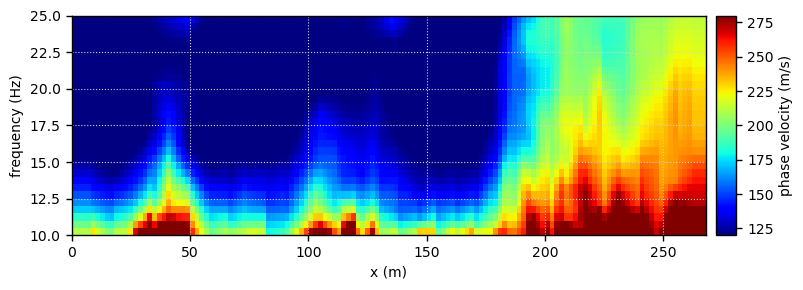

In [12]:
c_map = 'jet'

fig,ax = plt.subplots(figsize=(8,3))
swam.plot('pseudosection', method = typ, cmap = c_map, axes = ax,
                         vmin = 120, vmax = 280,
                         fmin  = 10, fmax = 25
         )
fig.suptitle(f'lam = {lam}, min_offset = {min_offset}, max_offset = {max_offset}, rel_err = {err_r}', fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(f'{prj_dir}/proc/tomo2D/04_figs/pseudo_tomo2d_smooth.png', dpi=200)

In [13]:
# Save the dispersion curves
swam.save(procset=procset, method=typ, dc_mode=0, format = 'csv')

Saving disperion curves to "../../data/real_data/proc/tomo2D/03_proc/tomo2D_tomo2D/Mode0" ..... 0.47 s
